# Variable Time Shift 

This notebook contains an example of performing a variable time shift.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import WDM
from WDM.code.discrete_wavelet_transform import WDM 

Let's start by creating an example signal. We will use a sine-Gaussian.

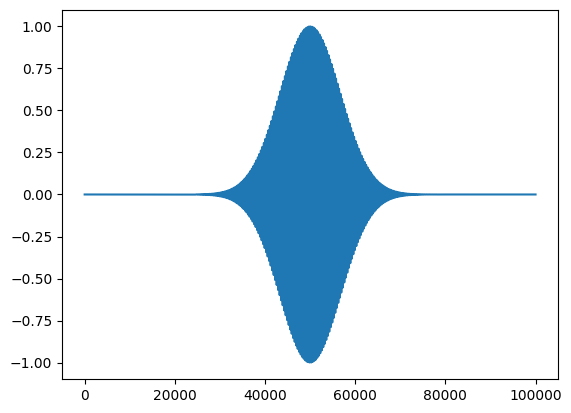

In [30]:
fs = 0.2    # sampling frequency [Hz]
T = 1.0e5   # duration [s]
f0 = 3.0e-3 # central frequency [Hz]
w = T/15.   # duration [s]

f = lambda t: np.exp(-0.5*((t-T/2.)/w)**2)*np.sin(2*np.pi*f0*t)

times = np.arange(0, T, 1/fs)
signal = f(times)

fig, ax = plt.subplots()
ax.plot(times, signal)
plt.show()

In [31]:
N = times.shape[0]
Nf = 200

wdm = WDM.WDM_transform(dt=1/fs, Nf=Nf, N=N, q=8, calc_m0=True)

In [32]:
print(wdm)

WDM_transform(Nf=200, N=20000, q=8, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 100 time cells
self.Nf = 200 frequency cells
self.dT = 1000.0 time resolution
self.dF = 0.0005 frequency resolution
self.dt = 5.0 time series cadence
self.df = 1e-05 time series fft frequency resolution
self.K = 3200 window length


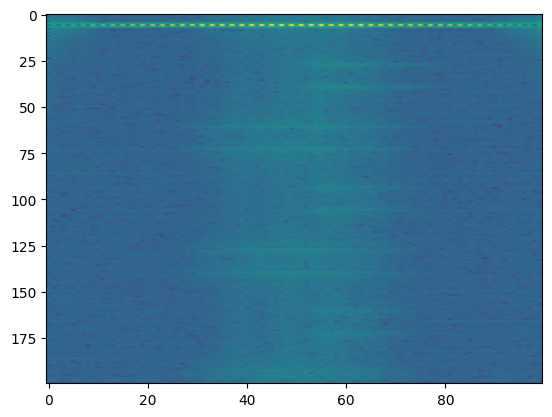

In [33]:
fig, ax = plt.subplots()
ax.imshow(np.log(np.abs(wdm(signal).T)), aspect='auto')
plt.show()

In [36]:
delta_constant = (T/10.) * np.ones(wdm.Nt)

In [35]:
delta_variable = (T/10.) * np.ones(wdm.Nt) + (T/10.)*np.arange(wdm.Nt)/wdm.Nt